In [1]:
"""
VahanBima CLTV Prediction Pipeline
==================================
Hackathon: Data Scientist Hiring Hackathon
Target: Predict Customer Lifetime Value(CLTV)
Metric: R**2 Score
Author: Aashish Bedi
"""

'\nVahanBima CLTV Prediction Pipeline\n==================================\nHackathon: Data Scientist Hiring Hackathon\nTarget: Predict Customer Lifetime Value(CLTV)\nMetric: R**2 Score\nAuthor: Aashish Bedi\n'

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
# 1. Load Data
# =========================================================
train = pd.read_csv('train_file.csv')
test = pd.read_csv('test_file.csv')
sub = pd.read_csv('sample_submission.csv')

print(f"Train: {train.shape} | Test: {test.shape}")

Train: (89392, 12) | Test: (59595, 11)


In [5]:
# 2. EDA
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Data Types ---")
print(train.dtypes)

print("\n--- First 5 Rows ---")
print(train.head())

print("\n--- Missing Values ---")
print(train.isnull().sum())

print("\n--- Statistical Summary ---")
print(train.describe())


--- Data Types ---
id                 int64
gender            object
area              object
qualification     object
income            object
marital_status     int64
vintage            int64
claim_amount       int64
num_policies      object
policy            object
type_of_policy    object
cltv               int64
dtype: object

--- First 5 Rows ---
   id  gender   area qualification         income  marital_status  vintage  \
0   1    Male  Urban      Bachelor         5L-10L               1        5   
1   2    Male  Rural   High School         5L-10L               0        8   
2   3    Male  Urban      Bachelor         5L-10L               1        8   
3   4  Female  Rural   High School         5L-10L               0        7   
4   5    Male  Urban   High School  More than 10L               1        6   

   claim_amount num_policies policy type_of_policy    cltv  
0          5790  More than 1      A       Platinum   64308  
1          5080  More than 1      A       Platinum  5

In [6]:
# Target Variable (CLTV) Analysis
plt.figure(figsize=(14, 4))

<Figure size 1400x400 with 0 Axes>

<Figure size 1400x400 with 0 Axes>

Text(0.5, 0, 'CLTV')

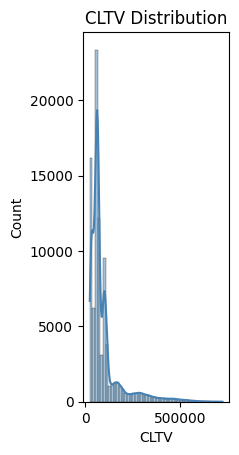

In [7]:
# Distribution
plt.subplot(1, 3, 1)
sns.histplot(train['cltv'], bins= 50, kde= True, color= 'steelblue')
plt.title('CLTV Distribution')
plt.xlabel('CLTV')

Text(0.5, 0, 'log(CLTV)')

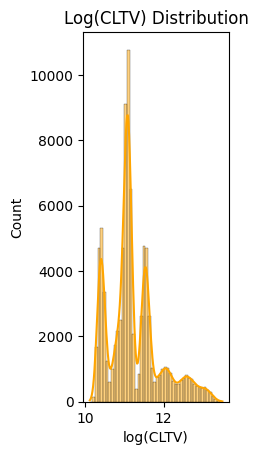

In [8]:
# Log distribution (since it's right skewed)
plt.subplot(1, 3, 2)
sns.histplot(np.log1p(train['cltv']), bins= 50, kde= True, color= 'orange')
plt.title("Log(CLTV) Distribution")
plt.xlabel('log(CLTV)')

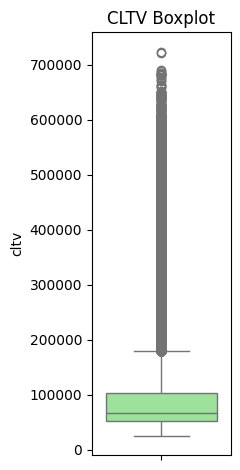

In [9]:
# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(y= train['cltv'], color= 'lightgreen')
plt.title('CLTV Boxplot')

plt.tight_layout()
plt.savefig('cltv_distribution.png')
plt.show()

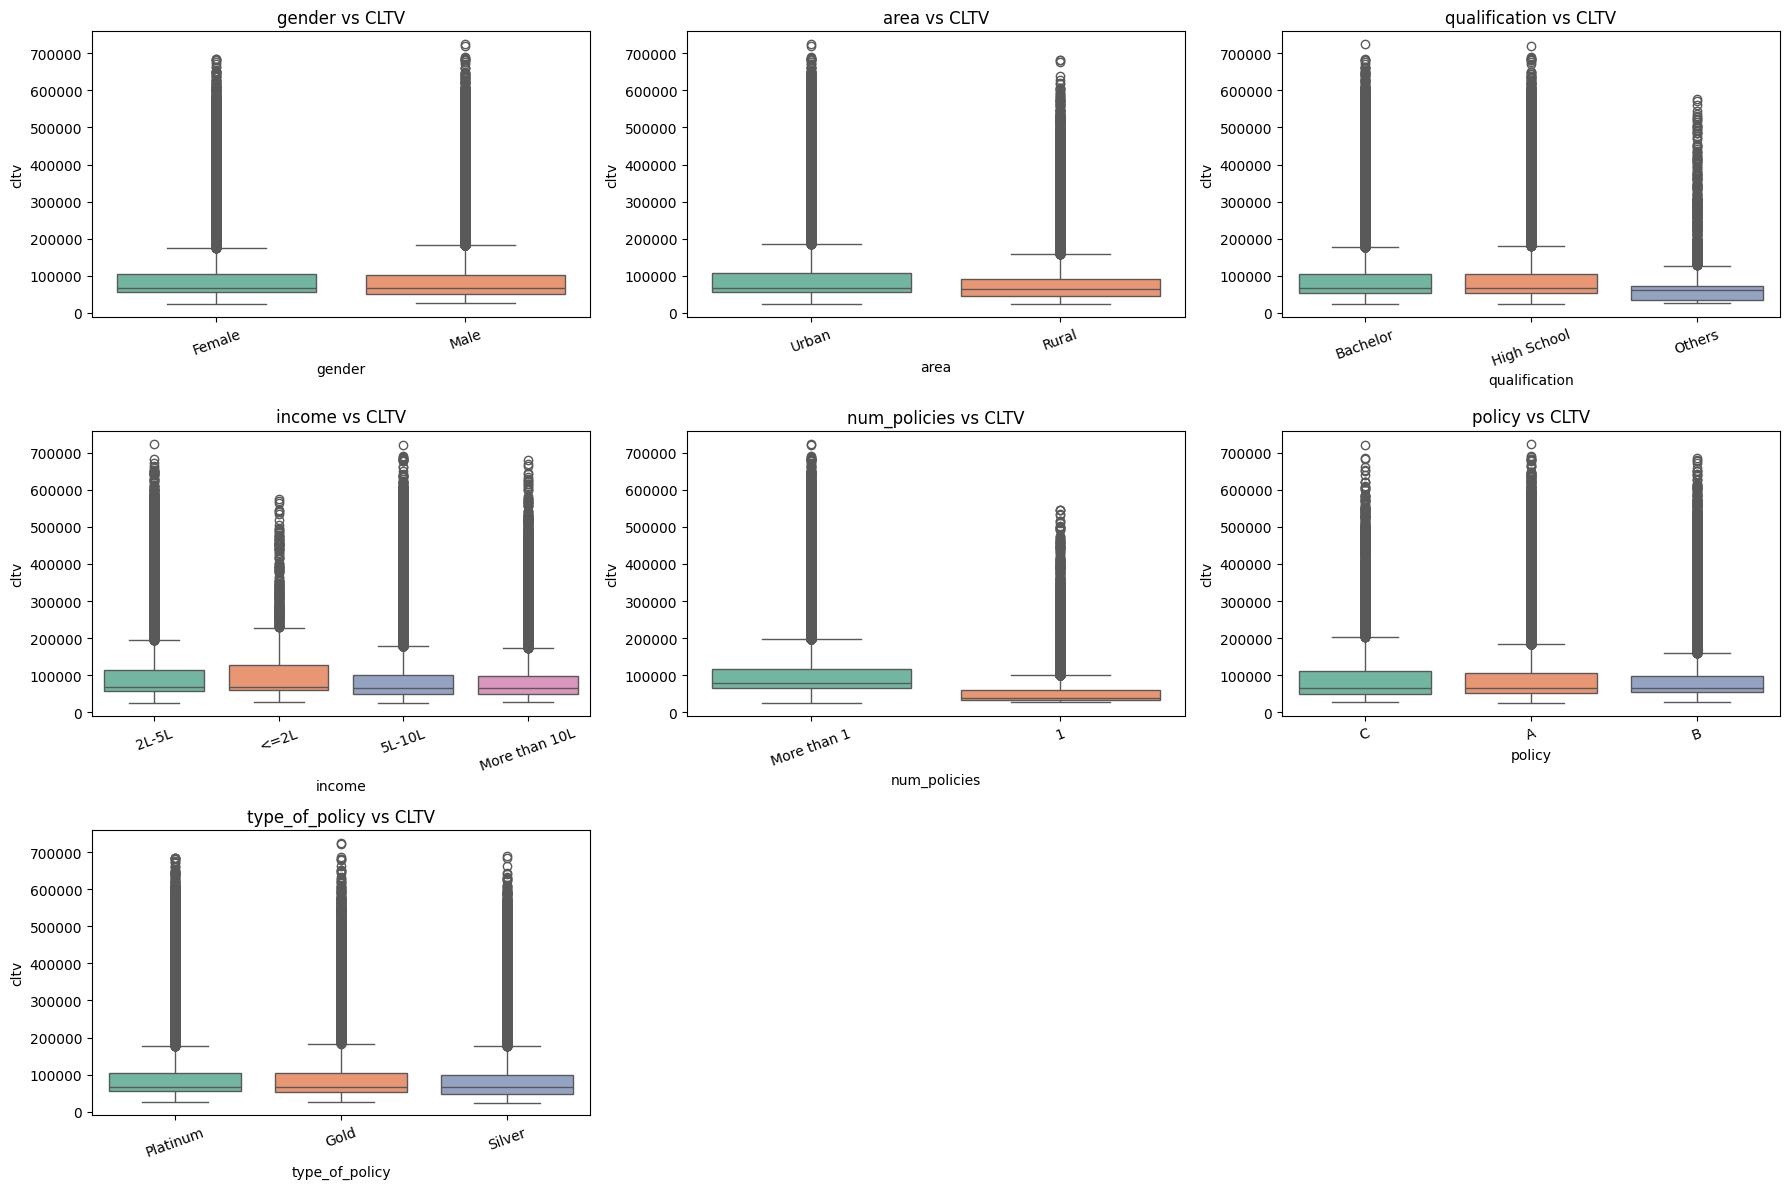

In [10]:
# Categorical Features vs CLTV
cat_cols = ['gender', 'area', 'qualification', 'income', 'num_policies', 'policy', 'type_of_policy']

plt.figure(figsize= (18, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    order = train.groupby(col)['cltv'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='cltv', order=order, palette='Set2')
    plt.title(f'{col} vs CLTV')
    plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig('categorical_vs_cltv.png')
plt.show()

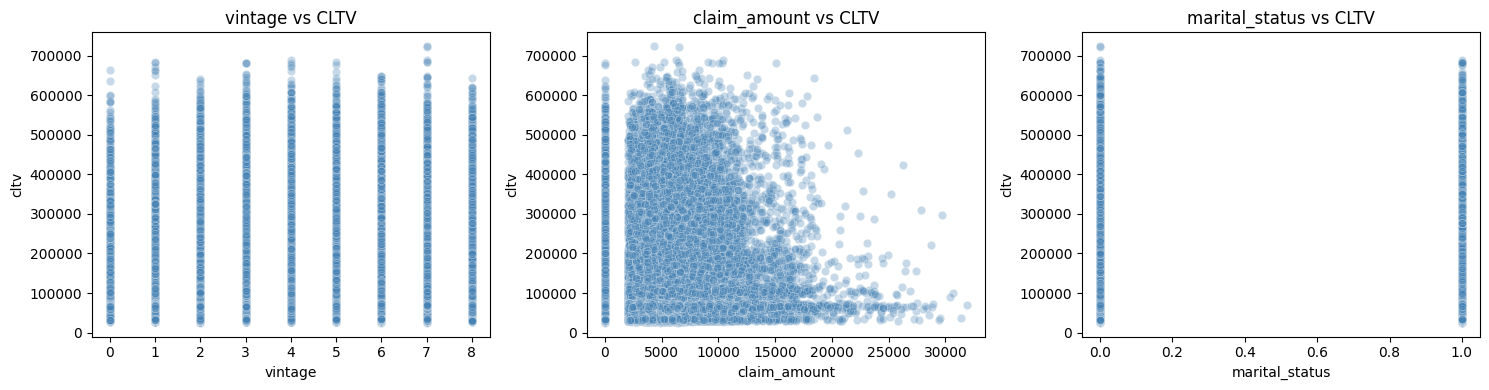

In [11]:
# Numerical Features vs CLTV
num_cols = ['vintage', 'claim_amount', 'marital_status']

plt.figure(figsize=(15, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(data= train, x=col, y='cltv', alpha=0.3, color='steelblue')
    plt.title(f'{col} vs CLTV')

plt.tight_layout()
plt.savefig('numerical_vs_cltv.png')
plt.show()

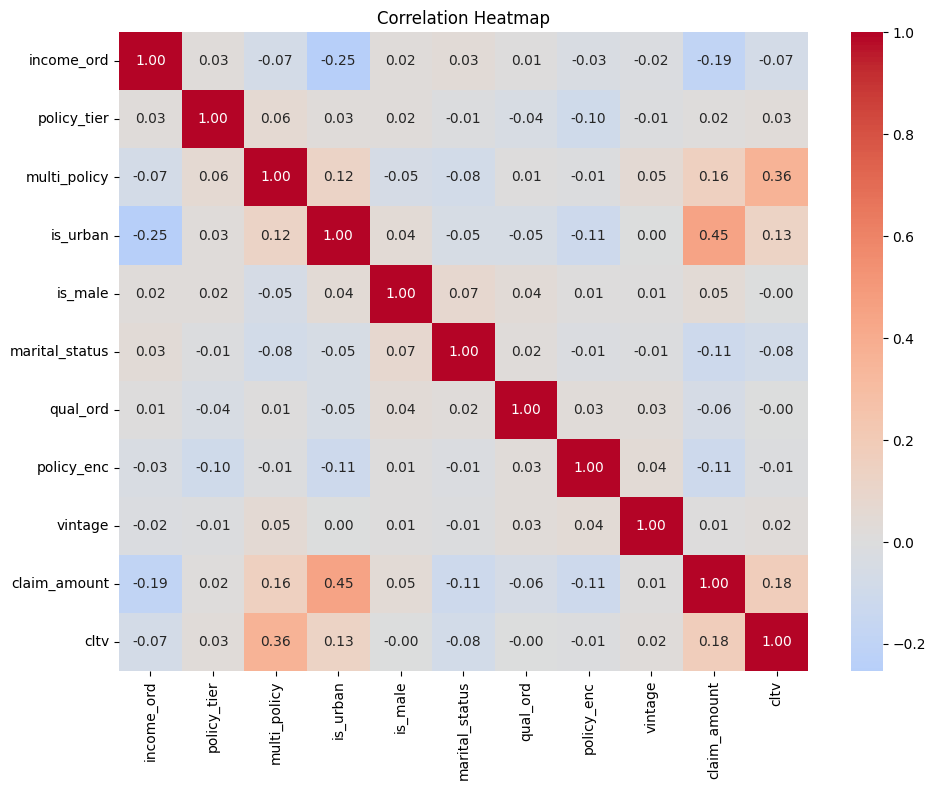

In [12]:
# CORRELATION HEATMAP
# Encode categoricals temporarily for correlation

train_enc = train.copy()
train_enc['income_ord']   = train_enc['income'].map({'<=2L':0, '2L-5L':1, '5L-10L':2, 'More than 10L':3})
train_enc['policy_tier']  = train_enc['type_of_policy'].map({'Silver':0, 'Gold':1, 'Platinum':2})
train_enc['multi_policy'] = (train_enc['num_policies'] == 'More than 1').astype(int)
train_enc['is_urban']     = (train_enc['area'] == 'Urban').astype(int)
train_enc['is_male']      = (train_enc['gender'] == 'Male').astype(int)
train_enc['qual_ord']     = train_enc['qualification'].map({'High School':0, 'Others':1, 'Bachelor':2})
train_enc['policy_enc']   = train_enc['policy'].map({'A':0, 'B':1,'C':2})

corr_cols = ['income_ord', 'policy_tier', 'multi_policy', 'is_urban', 'is_male',
             'marital_status', 'qual_ord', 'policy_enc', 'vintage', 'claim_amount', 'cltv']

plt.figure(figsize=(10, 8))
sns.heatmap(train_enc[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [13]:
# Value Counts for Categories
print("\n--- Value Counts ---")
for col in cat_cols:
    print(f"\n{col}:")
    print(train[col].value_counts())


--- Value Counts ---

gender:
gender
Male      50497
Female    38895
Name: count, dtype: int64

area:
area
Urban    62455
Rural    26937
Name: count, dtype: int64

qualification:
qualification
High School    46247
Bachelor       39399
Others          3746
Name: count, dtype: int64

income:
income
5L-10L           52716
2L-5L            21158
More than 10L    13664
<=2L              1854
Name: count, dtype: int64

num_policies:
num_policies
More than 1    60263
1              29129
Name: count, dtype: int64

policy:
policy
A    56644
B    24635
C     8113
Name: count, dtype: int64

type_of_policy:
type_of_policy
Platinum    47796
Silver      21010
Gold        20586
Name: count, dtype: int64


In [14]:
# CLTV STATS by Key Groups
print("\n--- Avg CLTV by type_of_policy ---")
print(train.groupby('type_of_policy')['cltv'].mean().sort_values(ascending=False))

print("\n--- Avg CLTV by income ---")
print(train.groupby('income')['cltv'].mean().sort_values(ascending=False))

print("\n--- Avg CLTV by num_policies ---")
print(train.groupby('num_policies')['cltv'].mean())

print("\n--- Avg CLTV by area ---")
print(train.groupby('area')['cltv'].mean())


--- Avg CLTV by type_of_policy ---
type_of_policy
Platinum    99752.960331
Gold        99381.983095
Silver      92457.367539
Name: cltv, dtype: float64

--- Avg CLTV by income ---
income
<=2L             111444.135922
2L-5L            109467.408073
5L-10L            95061.906670
More than 10L     89445.767564
Name: cltv, dtype: float64

--- Avg CLTV by num_policies ---
num_policies
1               50979.031618
More than 1    120658.299056
Name: cltv, dtype: float64

--- Avg CLTV by area ---
area
Rural     79587.316182
Urban    105873.921255
Name: cltv, dtype: float64


In [15]:
# 3. FEATURE ENGINEERING
# =========================================================

def feature_engineer(df):
    df = df.copy()

    # Ordinal encode income - natural ordering by income band
    income_order = ['<=2L', '2L-5L', '5L-10L', 'More than 10L']
    df['income_ord'] = df['income'].map({v: i for i,v in enumerate(income_order)})

    # Ordinal encode policy tier: Silver < Gold < Platinum
    df['policy_tier'] = df['type_of_policy'].map({'Silver':0, 'Gold':1, 'Platinum':2})

    # Binary: customer has more than 1 policy? (high CLV signal)
    df['multi_policy'] = (df['num_policies'] == 'More than 1').astype(int)

    # Binary flags for demographic features
    df['is_urban'] = (df['area'] == 'Urban').astype(int)
    df['is_male']  = (df['gender'] == 'Male').astype(int)

    # Ordinal encode qualification
    df['qual_ord'] = df['qualification'].map(
        {'High School':0, 'Others': 1, 'Bachelor':2}
    ).fillna(1)

    # Label encode policy type A/B/C
    df['policy_enc'] = df['policy'].map({'A': 0, 'B': 1, 'C': 2})

    # === Interaction features ===
    # Claim per vintage year -- normalize claim size by customer tenure
    df['claim_per_year'] = df['claim_amount'] / (df['vintage'] + 1)

    # Income level x vintage -- higher earners with longer tenure -> more valuable
    df['income_x_vintage'] = df['income_ord'] * df['vintage']

    # Policy tier x claim amount -- premium tier + high claim = most attention needed
    df['tier_x_claim'] = df['policy_tier'] * df['claim_amount']

    # Vintage x claim -- long-tenure high-claimers are a key segment
    df['vintage_x_claim'] = df['vintage'] * df['claim_amount']

    return df

In [16]:
# Apply feature engineering to both sets
train_fe = feature_engineer(train)
test_fe  = feature_engineer(test)

In [17]:
# Final feature list used for training
FEATURES = [
    'income_ord',       # Ordinal income level
    'policy_tier',      # Ordinal policy tier
    'multi_policy',     # Has more than 1 policy
    'is_urban',         # Urban vs  Rural
    'is_male',          # Gender flag
    'marital_status',   # 0 = Single, 1 = Married
    'qual_ord',         # Ordinal qualification
    'policy_enc',       # Policy type A/B/C
    'vintage',          # Customer tenure in years
    'claim_amount',     # Total claim amount
    'claim_per_year',   # Claim normalized by tenure
    'income_x_vintage', # Income * tenure interaction
    'tier_x_claim',     # Policy tier * claim interaction 
    'vintage_x_claim',  # Tenure * claim interaction
]

X      = train_fe[FEATURES]
y      = train['cltv']
X_test = test_fe[FEATURES]

In [18]:
# 4. CROSS-VALIDATION
# =========================================================

# 3-fold CV to validate R**2 before final training
kf = KFold(n_splits=3, shuffle=True, random_state=42)
rf_cv = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs= -1
)

cv_scores = cross_val_score(rf_cv, X, y, cv=kf, scoring='r2')
print(f"CV R**2 (3-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV R**2 (3-fold): 0.1537 ± 0.0013


In [19]:
# 5. FINAL MODEL TRAINING
# =========================================================

# RandomForestRegressor chosen for:
#   - Handles mixed feature types natively (no scaling needed)
#   - Robust to outliers in target (CLTV is right-skewed)
#   - Good interpretability via feature importances
#   - Ensemble reduces variance

model = RandomForestRegressor(
    n_estimators = 200,       # 200 trees for stable predictions
    max_depth = 12,           # Limit depth to avoid overfitting
    min_samples_leaf = 3,     # Each leaf needs at least 3 samples
    random_state = 42,
    n_jobs = -1               # Use all CPU cores
)

model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [20]:
# Feature importance analysis
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nFeature Importances:")
print(fi.round(4))


Feature Importances:
multi_policy        0.5006
claim_amount        0.1532
claim_per_year      0.0818
vintage_x_claim     0.0723
tier_x_claim        0.0643
income_x_vintage    0.0258
policy_enc          0.0211
is_urban            0.0183
qual_ord            0.0141
marital_status      0.0133
is_male             0.0125
income_ord          0.0102
vintage             0.0066
policy_tier         0.0058
dtype: float64


In [21]:
# 6. GENERATE PREDICTIONS & SUBMISSION
# =========================================================

preds = model.predict(X_test)

sub['cltv'] = preds
sub.to_csv('submission.csv', index = False)

In [22]:
print(f"\nSubmission saved!")
print(f"Prediction stats: mean={preds.mean():.0f}, min{preds.min():.0f}, max={preds.max():.0f}")
print(f"Sample:\n{sub.head()}")


Submission saved!
Prediction stats: mean=98257, min38454, max=268823
Sample:
      id           cltv
0  89393   83963.857898
1  89394  123808.168589
2  89395   94553.037100
3  89396   89082.289198
4  89397  131578.547840


In [25]:
# 8. SAVE MODEL
# ══════════════════════════════════════════════════════
import joblib

# Save the trained model to models folder
joblib.dump(model, 'C:/Users/91798/Desktop/Projects/Vidhya_Analytics/models/rf_cltv_model.pkl')
print("Model saved to models/rf_cltv_model.pkl")

# To verify — reload and test
loaded_model = joblib.load('C:/Users/91798/Desktop/Projects/Vidhya_Analytics/models/rf_cltv_model.pkl')
test_pred    = loaded_model.predict(X_test[:5])
print(f"Verification predictions: {test_pred}")

Model saved to models/rf_cltv_model.pkl
Verification predictions: [ 83963.85789811 123808.16858944  94553.0371005   89082.28919793
 131578.54784008]
